In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
import time

In [13]:
def load_and_filter():
    data = datasets.load_breast_cancer()
    X = data.data[:, :2]
    y = data.target
    print('missing values:\n',np.isnan(X).any())
    return X, y

In [14]:
class standardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        return self

    def transform(self, X):
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [15]:
def train_test_split_scaled(X, y, train_ratio=0.7, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    indices = np.random.permutation(n_samples)

    split_idx = int(train_ratio * n_samples)

    train_idx = indices[:split_idx]
    test_idx = indices[split_idx:]

    scaler = standardScaler()
    X_train = scaler.fit_transform(X[train_idx])
    X_test = scaler.transform( X[test_idx])

    return X_train, y[train_idx], X_test, y[test_idx]

In [16]:
def accuracy_score(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

In [ ]:
def run_model(X, y, kernel, C, gamma='scale', degree=3, n_seeds=10):
    train_accs =[]
    test_accs = []
    times = []
    n_svs = []
    last_run_data = {} 

    for seed in range(n_seeds): 
        X_train, y_train, X_test, y_test = train_test_split_scaled(X, y, train_ratio=0.7, random_state=seed)
        if kernel == 'poly':
            clf = SVC(kernel=kernel, C=C, degree=degree)
        else: # rbf
            clf = SVC(kernel=kernel, C=C, gamma=gamma)

        start_time = time.time()
        clf.fit(X_train, y_train)
        end_time = time.time()

        pred_train = clf.predict(X_train)
        pred_test = clf.predict(X_test)
        acc_train  = accuracy_score(y_train, pred_train)
        acc_test = accuracy_score(y_test, pred_test)
        time_length = (end_time - start_time)*1000
        svs = len(clf.support_vectors_)

        train_accs.append(acc_train)
        test_accs.append(acc_test)
        times.append(time_length)
        n_svs.append(svs)

        if seed == 0:
            last_run_data = {'model': clf, 'X': X_train, 'y': y_train}

    return {
        'Train_acc': np.mean(train_accs),
        'Test_acc': np.mean(test_accs),
        'Time': np.mean(times),
        'Support_vectors': np.mean(n_svs),
        'Plot_data': last_run_data
    }

In [18]:
def plot_decision_boundary(ax, clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

In [19]:
def plot_performance_curves(df, param_name, fixed_c, kernel_name):
    subset = df[df['C'] == fixed_c]
    plt.figure(figsize=(6, 4))
    
    x_vals = subset[param_name].astype(str)
    
    plt.plot(x_vals, subset['Train_acc'], 'o-', label='Train Acc')
    plt.plot(x_vals, subset['Test_acc'], 'o--', label='Test Acc')
    plt.title(f'{kernel_name} Kernel Performance (C={fixed_c})')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [20]:
def main():
    X, y = load_and_filter()
    
    C_values = [0.1, 1, 10]
    degrees = [2, 3, 4, 6]
    gammas = ['auto', 0.001, 0.01, 0.1, 1, 10, 100]
    
    results_poly = []
    results_rbf = []
    
    print("Running Polynomial Kernel Experiments...")
    fig_poly, axes_poly = plt.subplots(len(C_values), len(degrees), figsize=(15, 10))
    fig_poly.suptitle("Polynomial Kernel Decision Boundaries (Rows: C, Cols: Degree)")
    
    for i, C in enumerate(C_values):
        for j, deg in enumerate(degrees):
            res = run_model(X, y, 'poly', C, degree=deg)
            res.update({'C': C, 'Degree': deg})
            results_poly.append(res)
            
            plot_decision_boundary(axes_poly[i, j], res['Plot_data']['model'], 
                                   res['Plot_data']['X'], res['Plot_data']['y'], 
                                   f"C={C}, Deg={deg}")
    plt.tight_layout()
    plt.show()
    
    df_poly = pd.DataFrame(results_poly).drop(columns=['Plot_data'])
    print(df_poly)
    
    for C in C_values:
        plot_performance_curves(df_poly, 'Degree', C, 'Polynomial')

    print("\nRunning RBF Kernel Experiments...")
    fig_rbf, axes_rbf = plt.subplots(len(C_values), len(gammas), figsize=(20, 10))
    fig_rbf.suptitle("RBF Kernel Decision Boundaries (Rows: C, Cols: Gamma)")
    
    for i, C in enumerate(C_values):
        for j, gam in enumerate(gammas):
            res = run_model(X, y, 'rbf', C, gamma=gam)
            res.update({'C': C, 'Gamma': gam})
            results_rbf.append(res)
            
            plot_decision_boundary(axes_rbf[i, j], res['Plot_data']['model'], 
                                   res['Plot_data']['X'], res['Plot_data']['y'], 
                                   f"C={C}, g={gam}")
    plt.tight_layout()
    plt.show()

    df_rbf = pd.DataFrame(results_rbf).drop(columns=['Plot_data'])
    print(df_rbf)

    for C in C_values:
        plot_performance_curves(df_rbf, 'Gamma', C, 'RBF')

missing values:
 False
Running Polynomial Kernel Experiments...


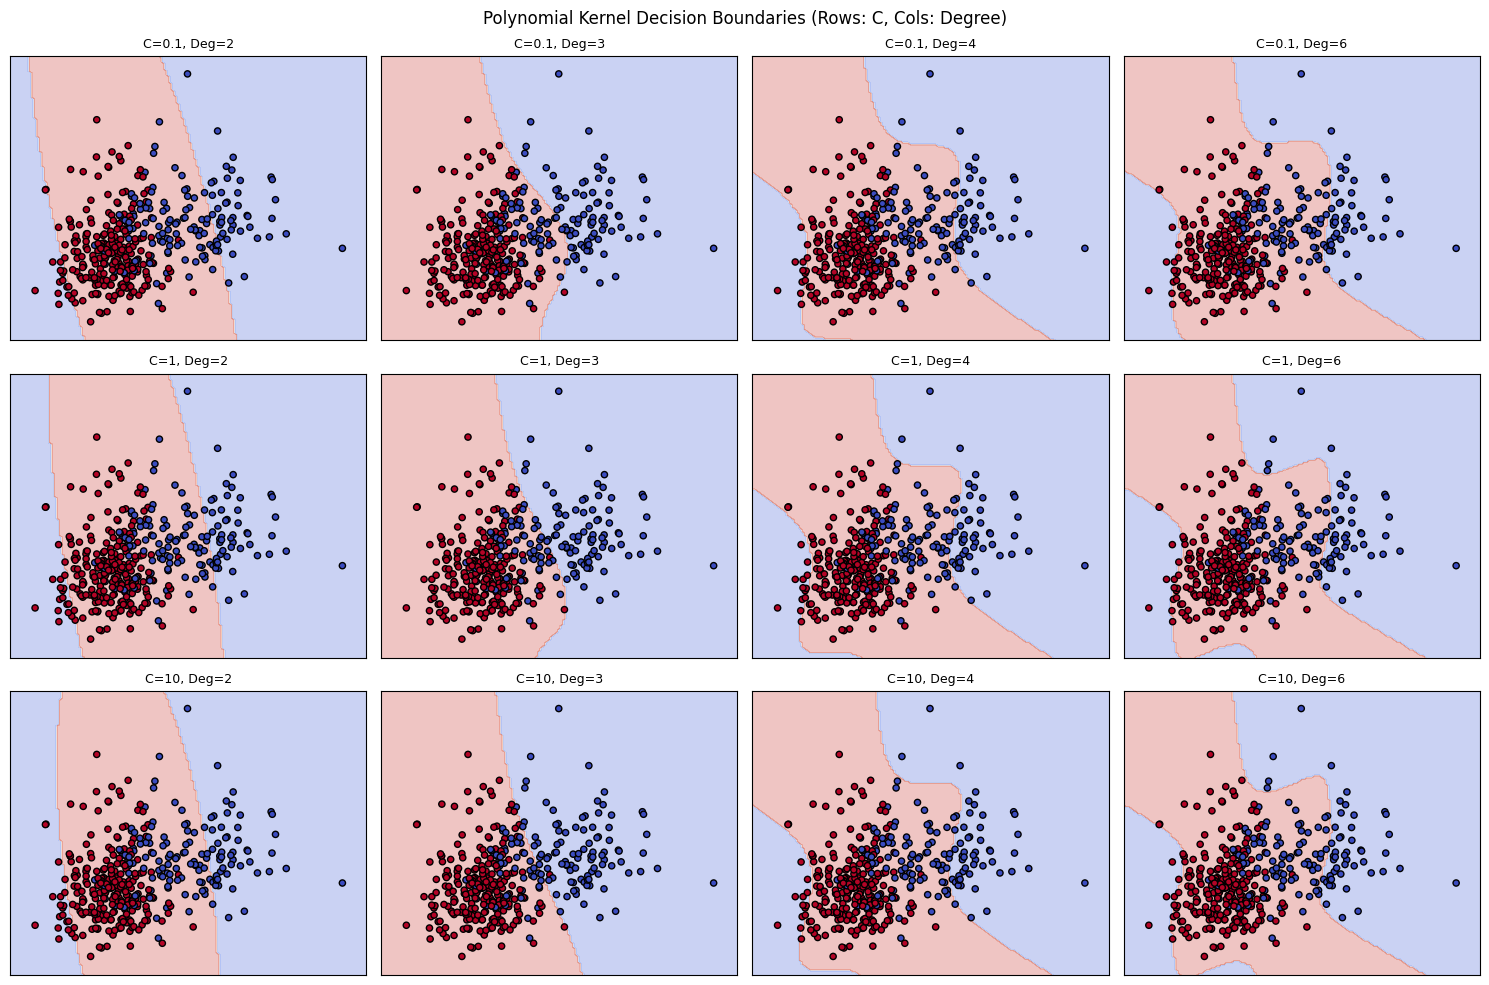

    Train_acc  Test_acc       Time  Support_vectors     C  Degree
0    0.707286  0.699415   2.992463            268.8   0.1       2
1    0.815075  0.796491   3.059053            185.3   0.1       3
2    0.715578  0.700000   3.158879            248.4   0.1       4
3    0.718593  0.694737   5.446696            242.2   0.1       6
4    0.711055  0.700000   2.986240            259.8   1.0       2
5    0.845729  0.829825   2.000880            145.9   1.0       3
6    0.717337  0.702339   4.835558            241.5   1.0       4
7    0.722613  0.700000  12.508368            236.9   1.0       6
8    0.711809  0.703509   6.160069            259.1  10.0       2
9    0.869095  0.846784   3.187323            126.5  10.0       3
10   0.717839  0.704094  16.448498            240.1  10.0       4
11   0.721859  0.699415  96.323037            235.6  10.0       6


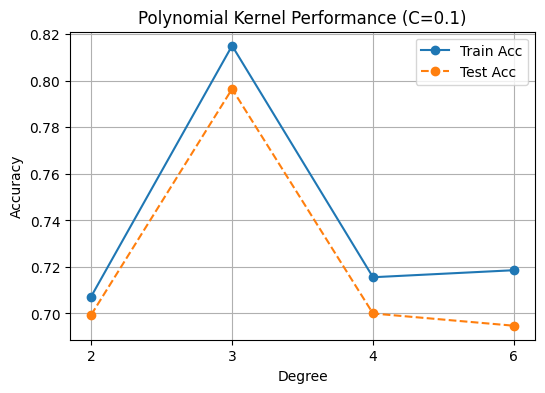

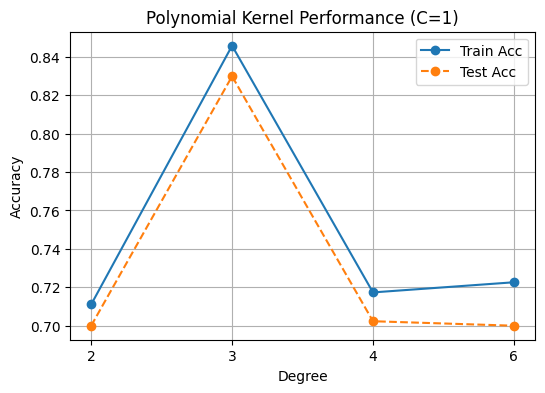

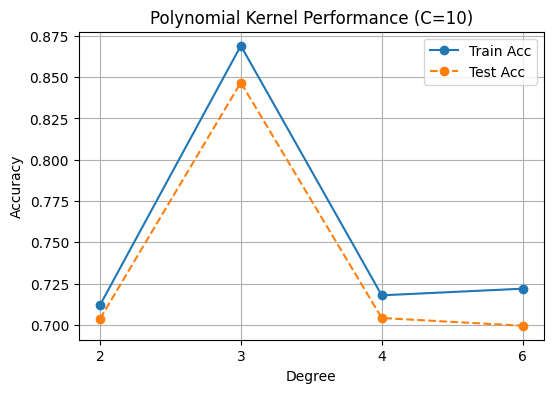


Running RBF Kernel Experiments...


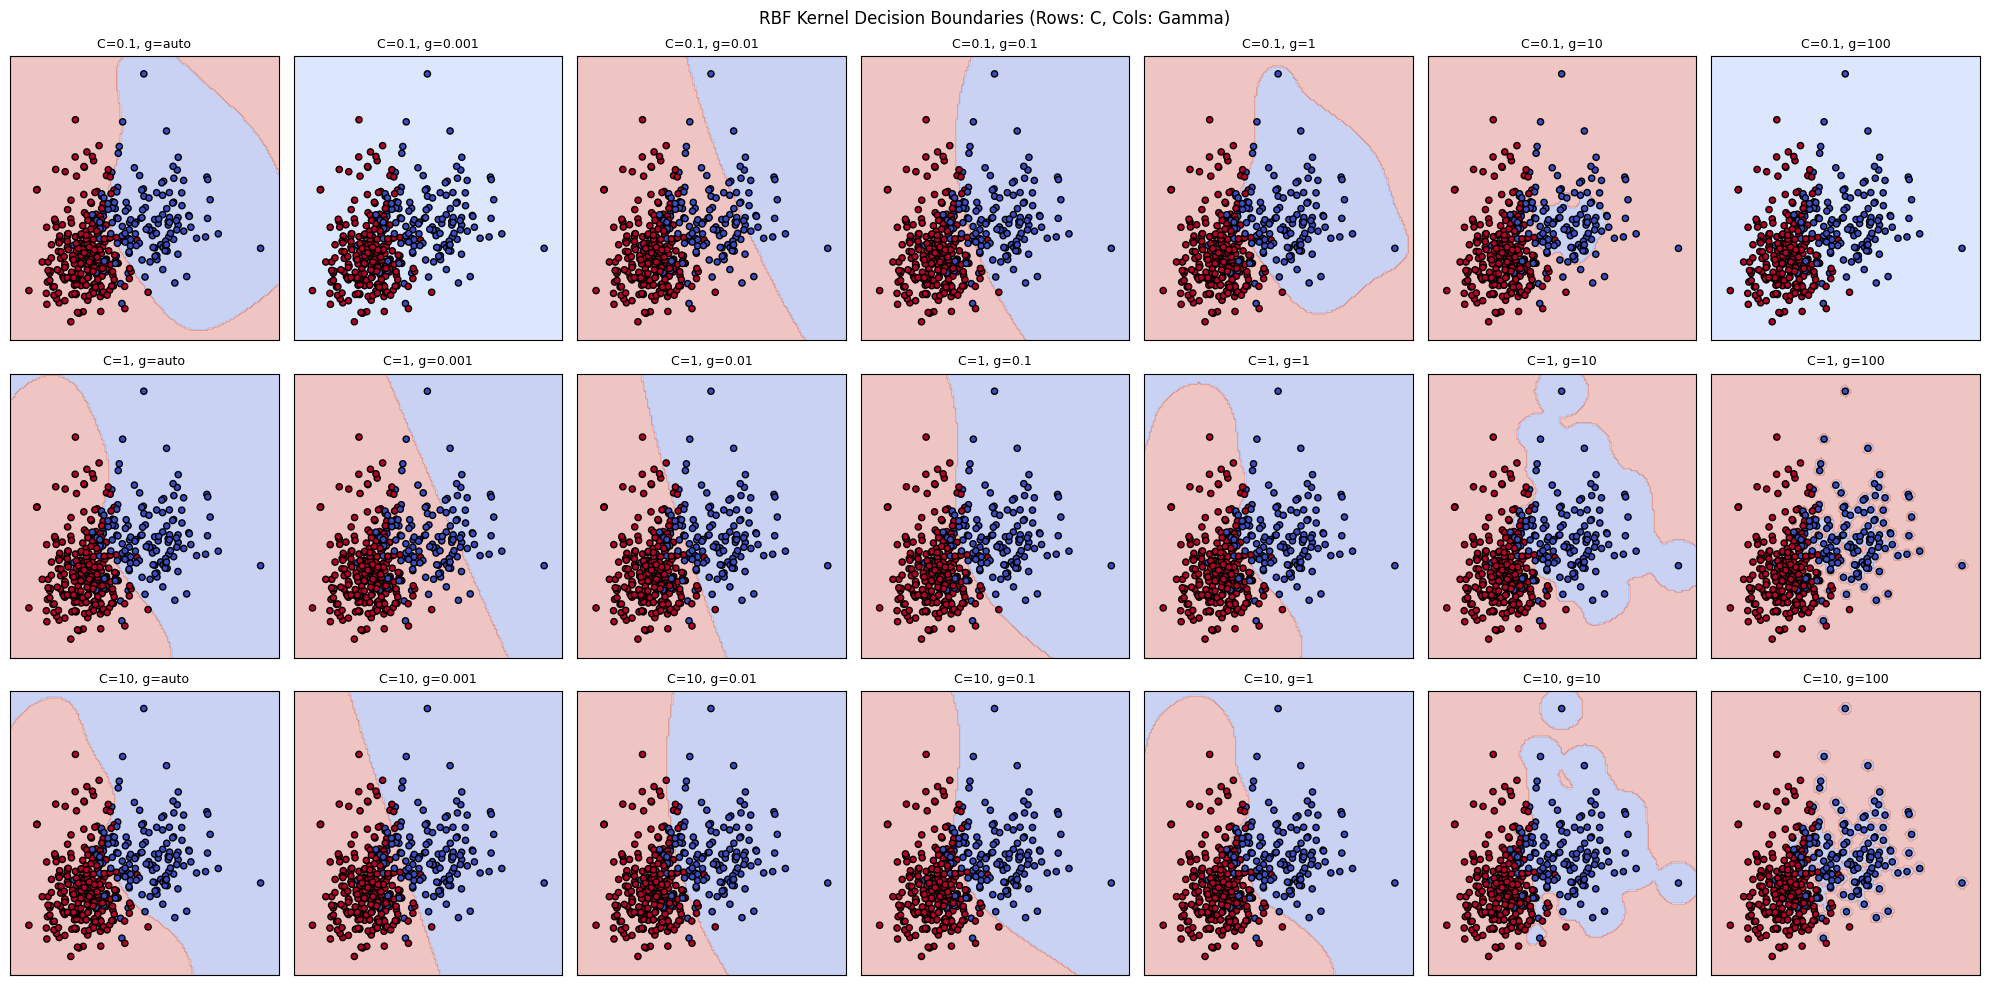

    Train_acc  Test_acc      Time  Support_vectors     C  Gamma
0    0.906281  0.893567  2.443433            179.0   0.1   auto
1    0.627136  0.628070  3.311205            296.8   0.1  0.001
2    0.708040  0.698830  3.188992            296.9   0.1   0.01
3    0.890452  0.869006  2.455974            201.7   0.1    0.1
4    0.907789  0.893567  2.433467            193.6   0.1      1
5    0.818844  0.775439  4.298544            323.8   0.1     10
6    0.627136  0.628070  5.231023            365.8   0.1    100
7    0.911307  0.892982  1.890063            113.7   1.0   auto
8    0.720352  0.709357  3.214598            296.4   1.0  0.001
9    0.882161  0.860234  2.327776            188.2   1.0   0.01
10   0.905779  0.892982  1.805758            124.5   1.0    0.1
11   0.914322  0.894737  2.159119            118.8   1.0      1
12   0.919095  0.876608  4.848766            229.8   1.0     10
13   0.970352  0.768421  5.737185            360.7   1.0    100
14   0.912814  0.890058  2.968121       

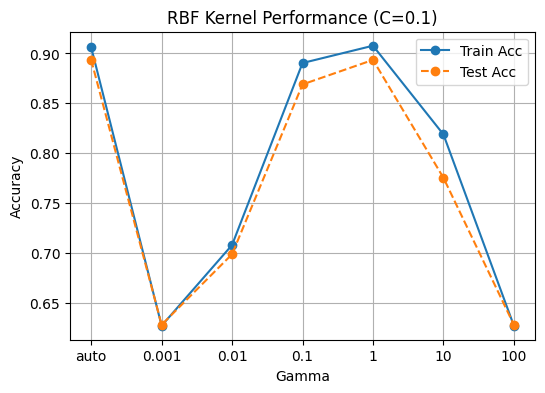

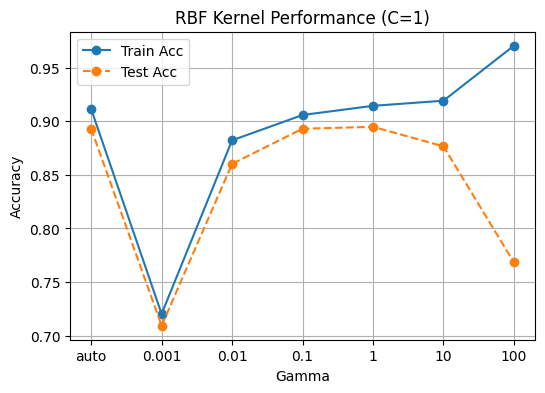

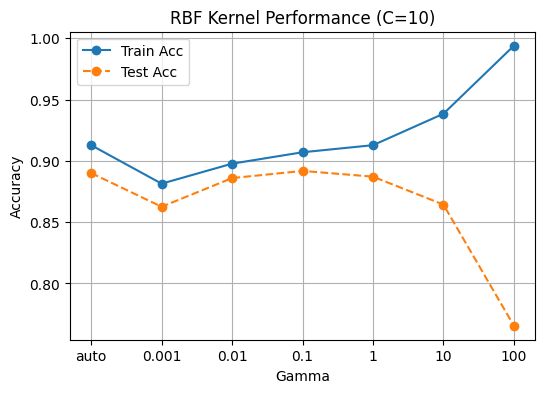

In [21]:
if __name__ == "__main__":
    main()